# Deep Checkpoint Analysis + Fair Evaluation

In [1]:
import numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from pathlib import Path; import json,warnings,sys,os,pickle
warnings.filterwarnings('ignore'); sns.set_style('whitegrid'); plt.rcParams['figure.dpi']=120
NB=Path('/home/aymen/Documents/GitHub/Federated-Continual-learning-/New/notebooks_sandbox')
PROJ=NB.parent; sys.path.insert(0,str(PROJ)); sys.path.insert(0,str(NB/'core_modules'))
LAYER_DELIMS=[208,1414,1514,2254,2464]; LAYER_NAMES=['conv1','conv2','conv3','fc1','fc2']
COLORS={'i1':'#1f77b4','i2':'#ff7f0e','pred':'#2ca02c','gt':'#d62728','fn1':'#9467bd','fn2':'#8c564b','fn3':'#e377c2','fn4':'#7f7f7f','fn5':'#bcbd22'}
DATA_DIR=NB/'paper_results'/'deep_analysis'
FAIR_DIR=NB/'paper_results'/'fair_eval'
print('Deep analysis experiments:'); [print(f'  {d.name}') for d in sorted(DATA_DIR.iterdir()) if d.is_dir() and (d/'df1_weights.pkl').exists()]
print('Fair eval results:'); [print(f'  {f.name}') for f in sorted(FAIR_DIR.glob('*.csv'))] if FAIR_DIR.exists() else print('  (none yet)')

Deep analysis experiments:
  tiny_overlap0_AUTO
  tiny_overlap0_DiffPers
  tiny_overlap0_FFT
  tiny_overlap0_FFT_0.1xMelSpec
  tiny_overlap0_FIM
  tiny_overlap0_LWLN
  tiny_overlap0_LW_DiffPers
  tiny_overlap0_LW_FFT
  tiny_overlap0_LW_FFT_0.1xLW_MelSpec
  tiny_overlap0_LW_MAE
  tiny_overlap0_LW_MAE_0.1xLW_DiffPers
  tiny_overlap0_LW_MAPE
  tiny_overlap0_LW_MAPE_0.1xLW_JS
  tiny_overlap0_LW_MSE
  tiny_overlap0_LW_MSE_0.01xLW_PersLandscape
  tiny_overlap0_LW_MSE_0.05xLW_Frobenius
  tiny_overlap0_LW_MSE_0.05xLW_RTD
  tiny_overlap0_LW_MSE_0.1xLW_DiffPers
  tiny_overlap0_LW_MSE_0.1xLW_LogNorm
  tiny_overlap0_LW_RTD
  tiny_overlap0_LW_Sinkhorn
  tiny_overlap0_MAE
  tiny_overlap0_MAE_0.05xRTD
  tiny_overlap0_MAE_0.1xDiffPers
  tiny_overlap0_MAPE
  tiny_overlap0_MAPE_0.1xJS
  tiny_overlap0_MSE
  tiny_overlap0_MSE_0.01xPersLandscape
  tiny_overlap0_MSE_0.05xFrobenius
  tiny_overlap0_MSE_0.05xRTD
  tiny_overlap0_MSE_0.15xSinkhorn
  tiny_overlap0_MSE_0.1xDiffPers
  tiny_overlap0_MSE_0.1xLogNorm


[]

## 0. Fair Evaluation (run if no CSV exists)

In [2]:
# Run fair_evaluation.py silently if results don't exist yet
FAIR_CSV = FAIR_DIR / 'fair_eval_all.csv'
if not FAIR_CSV.exists():
    print('Running fair_evaluation.py (no-cnn quick pass)...')
    !cd {NB} && conda run -n FCL python3 scripts/fair_evaluation.py --no-cnn --overlaps 0 1 2 2>&1 | tail -5
    print('Now running with CNN (10 samples/exp)...')
    !cd {NB} && conda run -n FCL python3 scripts/fair_evaluation.py --overlaps 0 1 2 --n-cnn-samples 10 --resume 2>&1 | tail -10
else:
    print(f'Fair eval CSV exists: {FAIR_CSV}')
fair_df = pd.read_csv(FAIR_CSV) if FAIR_CSV.exists() else pd.DataFrame()
print(f'Fair eval: {fair_df.shape}') if len(fair_df)>0 else print('No fair eval data')

Running fair_evaluation.py (no-cnn quick pass)...
Evaluating: 100%|██████████| 105/105 [00:40<00:00,  2.61it/s]


Now running with CNN (10 samples/exp)...
  SKIP (already done): tiny_overlap2_MAPE_0.1xJS
  SKIP (already done): tiny_overlap2_MSE
  SKIP (already done): tiny_overlap2_MSE_0.05xFrobenius
  SKIP (already done): tiny_overlap2_MSE_0.05xRTD
  SKIP (already done): tiny_overlap2_MSE_0.1xDiffPers
  SKIP (already done): tiny_overlap2_MSE_0.1xLogNorm
  SKIP (already done): tiny_overlap2_RTD
  SKIP (already done): tiny_overlap2_Sinkhorn
No results to write.

Fair eval: (105, 20)


## 1. Load 3 Dataframes

In [3]:
EXP_NAME='tiny_overlap0_MSE'  # CHANGE THIS
exp_dir=DATA_DIR/EXP_NAME
assert exp_dir.exists(), f'{exp_dir} not found. Run checkpoint_deep_analysis.py first.'
df1=pd.read_pickle(exp_dir/'df1_weights.pkl')
df2=pd.read_pickle(exp_dir/'df2_eigenvalues.pkl')
df3=pd.read_pickle(exp_dir/'df3_topology.pkl')
with open(exp_dir/'selected_scales.json') as f: scales=json.load(f)
print(f'DF1 weights:     {df1.shape}')
print(f'DF2 eigenvalues: {df2.shape}')
print(f'DF3 topology:    {df3.shape}')
print(f'Scales:          {scales}')

DF1 weights:     (100, 16)
DF2 eigenvalues: (900, 29)
DF3 topology:    (900, 19)
Scales:          {'optimal': 'sub60_nl20', 'breakpoint': 'sub120_nl20', 'meta': 'sub60_nl10'}


## 2. Weight Vectors (DF1)

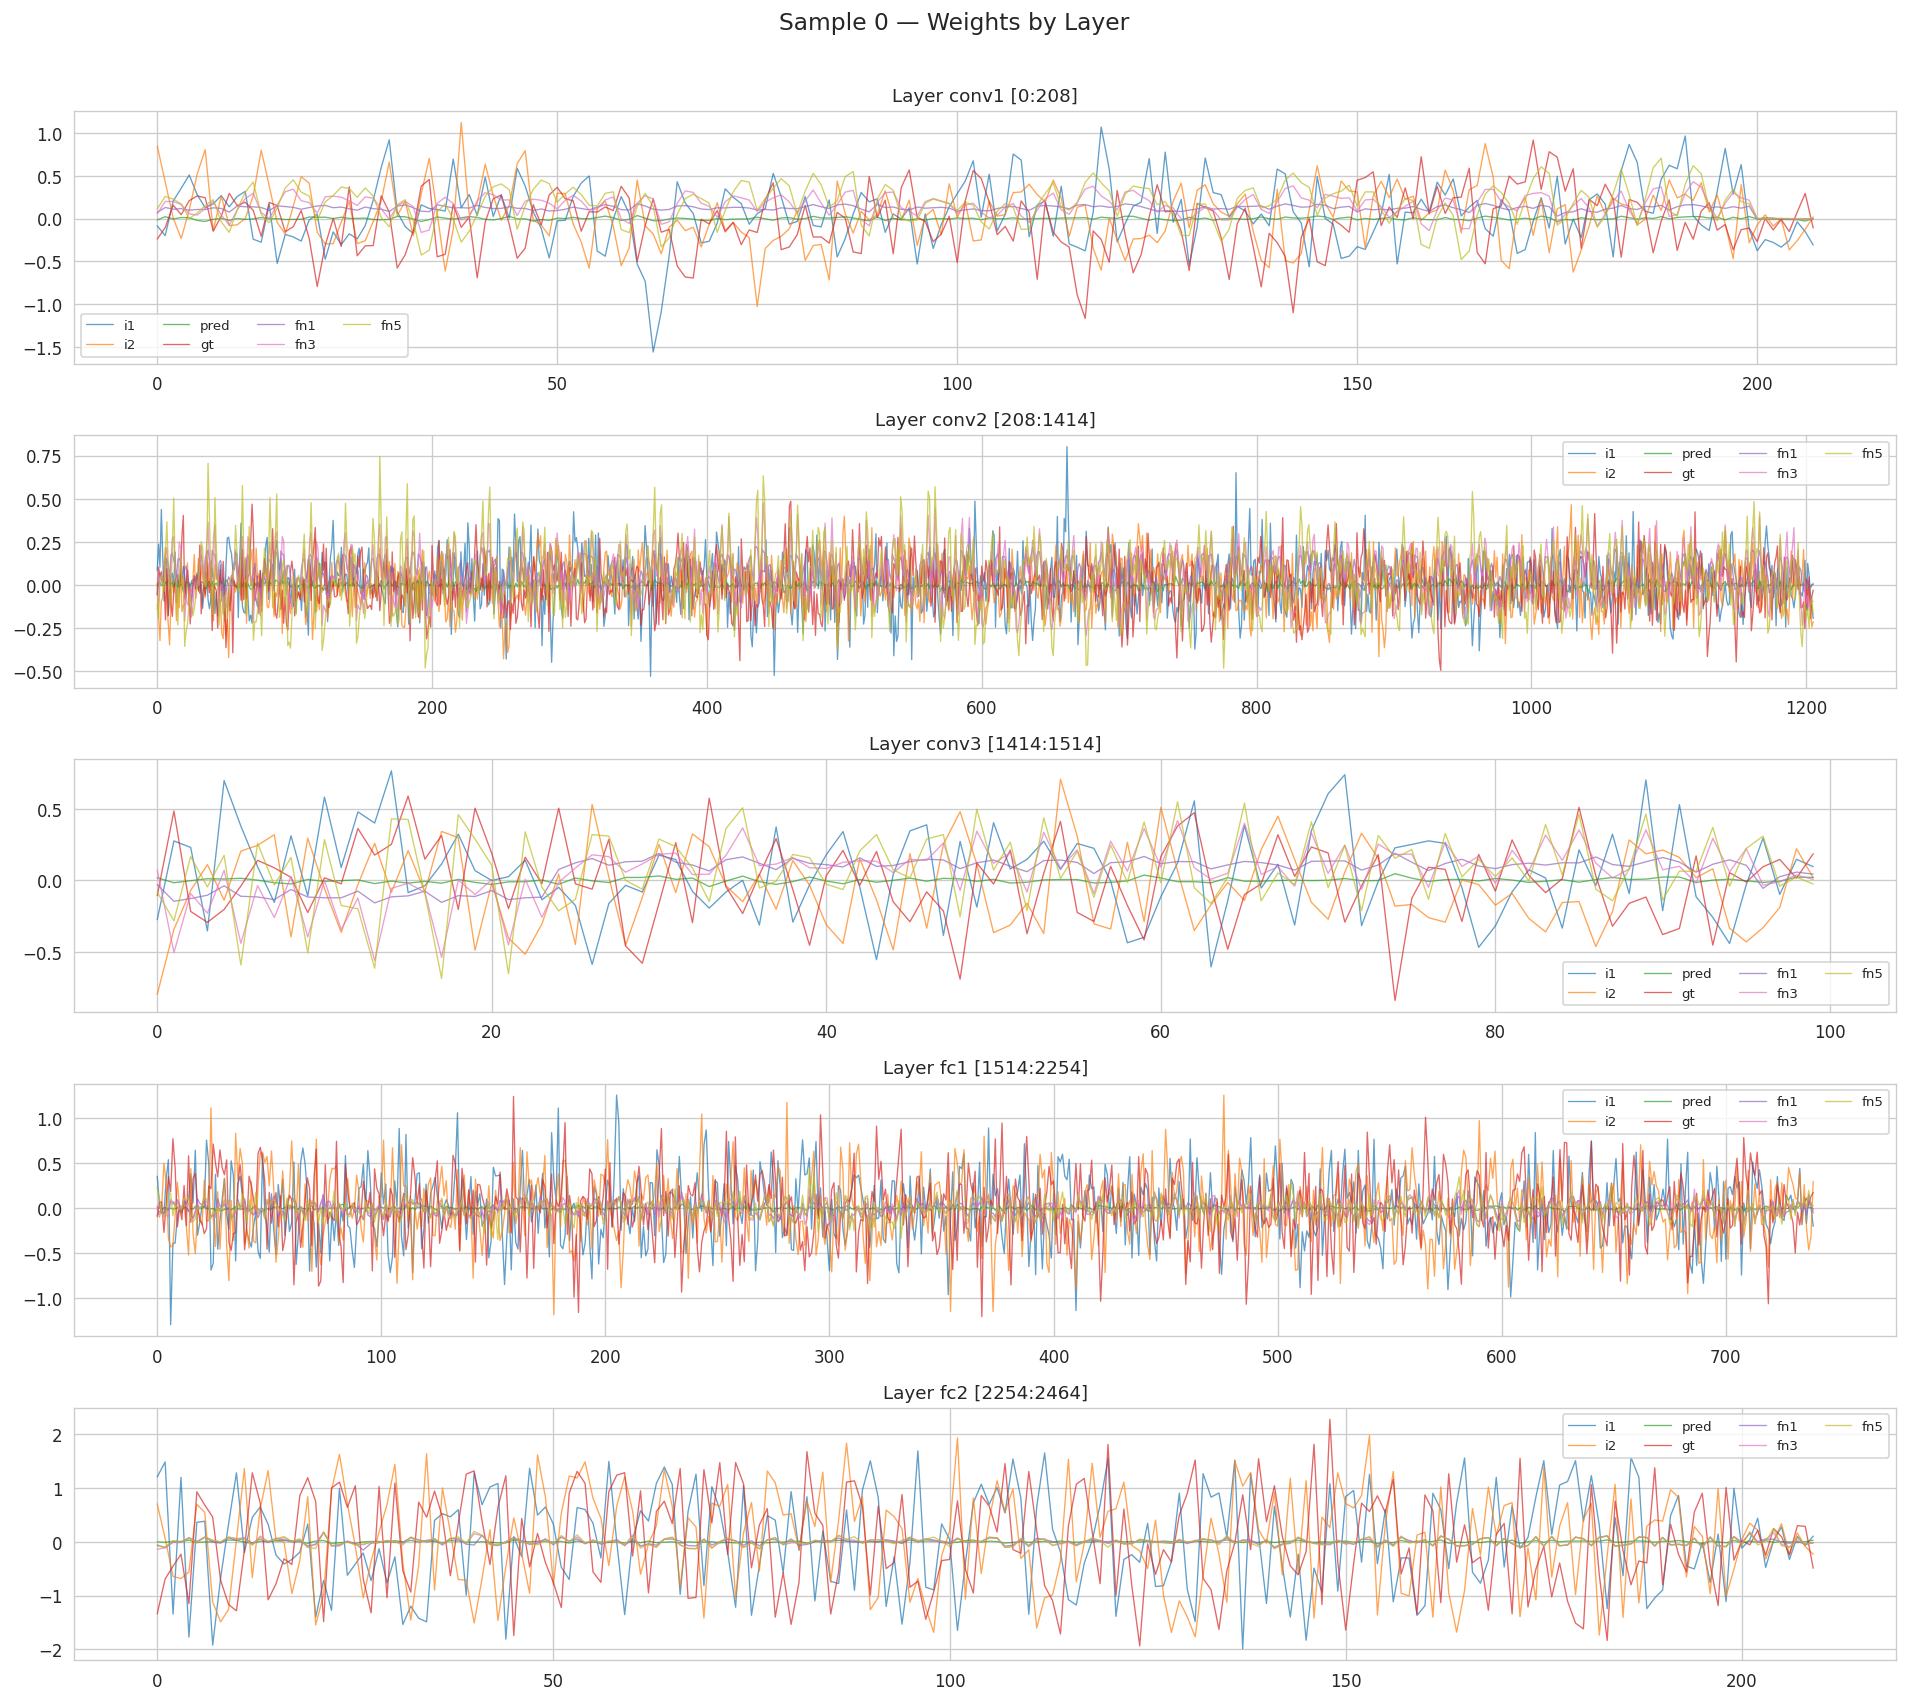

In [4]:
def plot_weights(si=0):
    r=df1.iloc[si]; fig,axes=plt.subplots(5,1,figsize=(16,14)); prev=0
    for ax,(end,nm) in zip(axes,zip(LAYER_DELIMS,LAYER_NAMES)):
        for wt in ['i1','i2','pred','gt','fn1','fn3','fn5']:
            if wt in r and r[wt] is not None:
                ax.plot(np.array(r[wt])[prev:end],label=wt,alpha=.7,color=COLORS.get(wt,'k'),lw=.8)
        ax.set_title(f'Layer {nm} [{prev}:{end}]',fontsize=11); ax.legend(fontsize=8,ncol=4); prev=end
    fig.suptitle(f'Sample {si} — Weights by Layer',fontsize=14,y=1.01); plt.tight_layout(); return fig
plot_weights(0); plt.show()

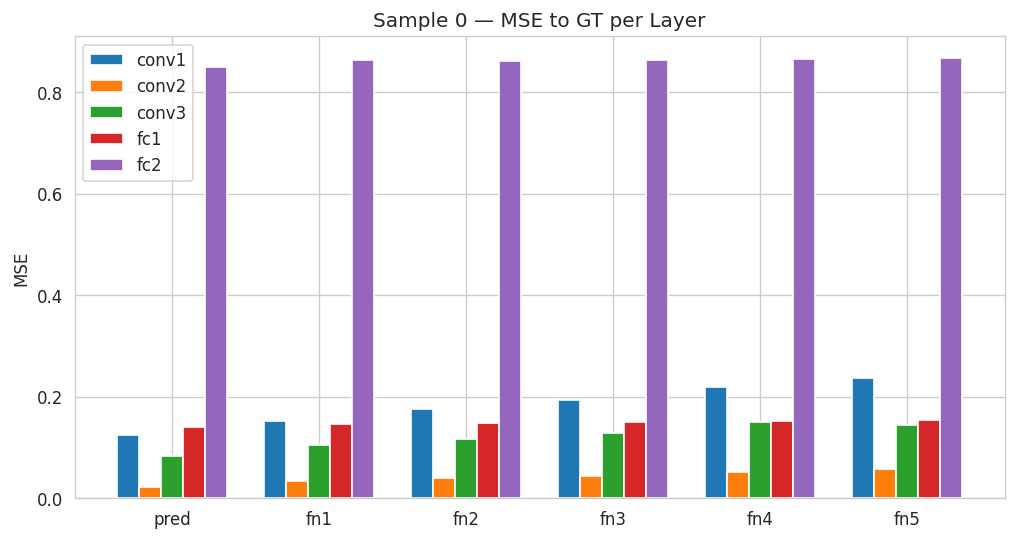

In [5]:
# MSE per layer across finetune epochs
def plot_fn_mse(si=0):
    r=df1.iloc[si]; gt=np.array(r['gt']); labels=['pred']+[f'fn{e}' for e in range(1,6)]
    prev=0; lmse={nm:[] for nm in LAYER_NAMES}
    for end,nm in zip(LAYER_DELIMS,LAYER_NAMES):
        for k in labels:
            if k in r and r[k] is not None: lmse[nm].append(np.mean((np.array(r[k])[prev:end]-gt[prev:end])**2))
            else: lmse[nm].append(np.nan)
        prev=end
    fig,ax=plt.subplots(figsize=(10,5)); x=np.arange(len(labels)); w=.15
    for i,nm in enumerate(LAYER_NAMES): ax.bar(x+i*w,lmse[nm],w,label=nm)
    ax.set_xticks(x+2*w); ax.set_xticklabels(labels); ax.set_ylabel('MSE')
    ax.set_title(f'Sample {si} — MSE to GT per Layer'); ax.legend(); return fig
plot_fn_mse(0); plt.show()

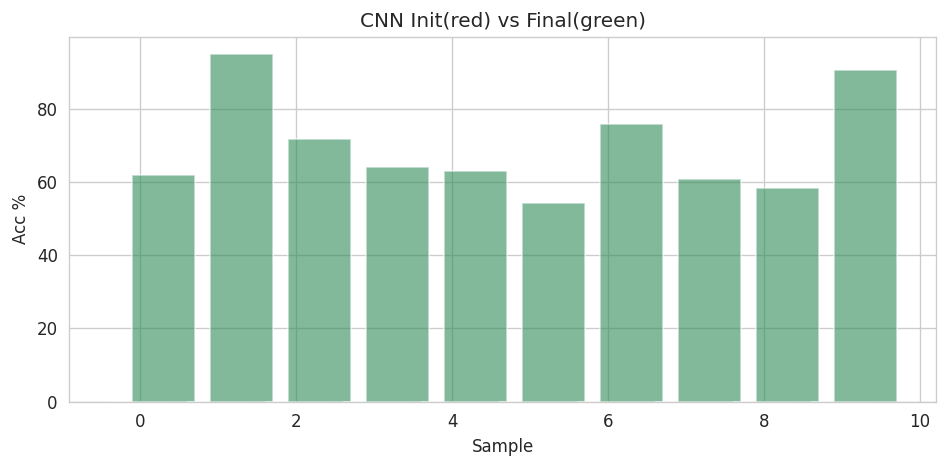

In [6]:
# CNN accuracy
fig,ax=plt.subplots(figsize=(8,4))
for i in range(min(10,len(df1))):
    ax.bar(i,df1.iloc[i]['cnn_acc_init'],color='salmon',alpha=.6)
    ax.bar(i+.3,df1.iloc[i]['cnn_acc_final'],color='seagreen',alpha=.6)
ax.set_xlabel('Sample'); ax.set_ylabel('Acc %'); ax.set_title('CNN Init(red) vs Final(green)'); plt.tight_layout(); plt.show()

## 3. Eigenvalue Spectrum (DF2)

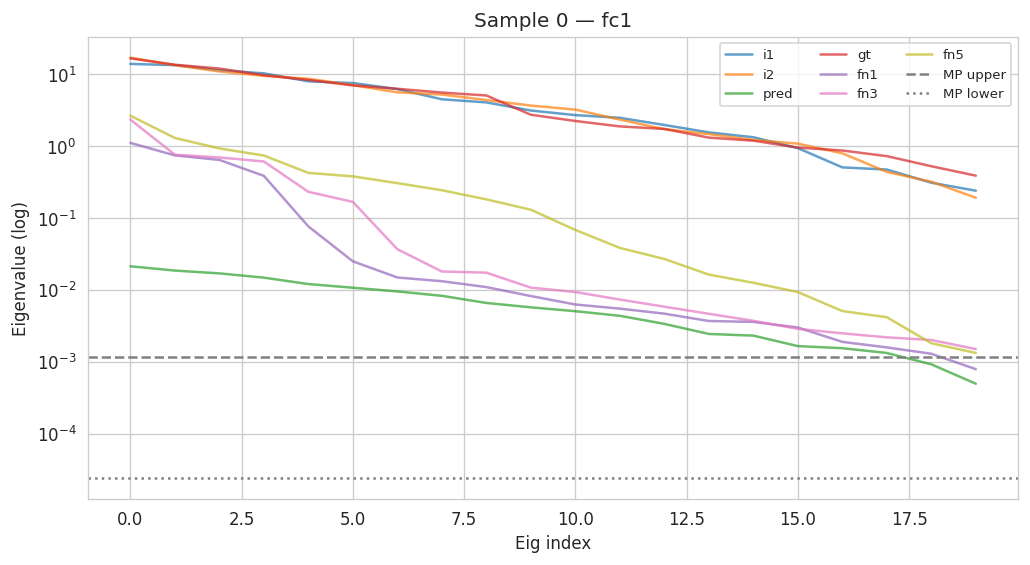

In [7]:
def plot_eig(si=0,layer='fc1'):
    sub=df2[df2['sample']==si]; fig,ax=plt.subplots(figsize=(10,5))
    for wt in ['i1','i2','pred','gt','fn1','fn3','fn5']:
        row=sub[sub['weight_type']==wt]
        if len(row)==0: continue
        eigs=np.array(row.iloc[0][f'eig_{layer}'])
        ax.semilogy(range(len(eigs)),eigs,label=wt,alpha=.7,color=COLORS.get(wt,'k'))
    r=sub[sub['weight_type']=='pred'].iloc[0]
    ax.axhline(r[f'mp_max_{layer}'],color='grey',ls='--',label='MP upper')
    ax.axhline(r[f'mp_min_{layer}'],color='grey',ls=':',label='MP lower')
    ax.set_xlabel('Eig index'); ax.set_ylabel('Eigenvalue (log)'); ax.set_title(f'Sample {si} — {layer}'); ax.legend(fontsize=8,ncol=3); return fig
plot_eig(0,'fc1'); plt.show()

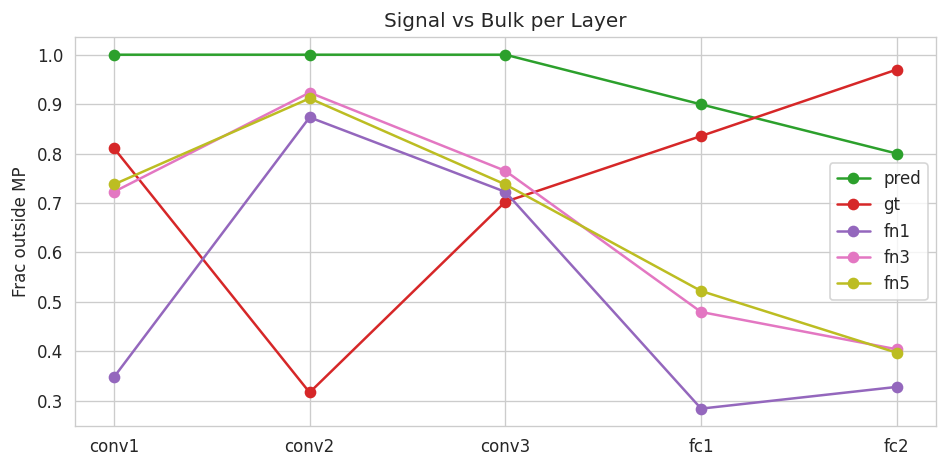

In [8]:
# Fraction outside MP bulk
fig,ax=plt.subplots(figsize=(8,4))
for wt in ['pred','gt','fn1','fn3','fn5']:
    sub=df2[df2['weight_type']==wt]
    vals=[sub[f'frac_outside_mp_{ln}'].mean() for ln in LAYER_NAMES]
    ax.plot(LAYER_NAMES,vals,'o-',label=wt,color=COLORS.get(wt,'k'))
ax.set_ylabel('Frac outside MP'); ax.set_title('Signal vs Bulk per Layer'); ax.legend(); plt.tight_layout(); plt.show()

## 4. Persistent Homology (DF3)

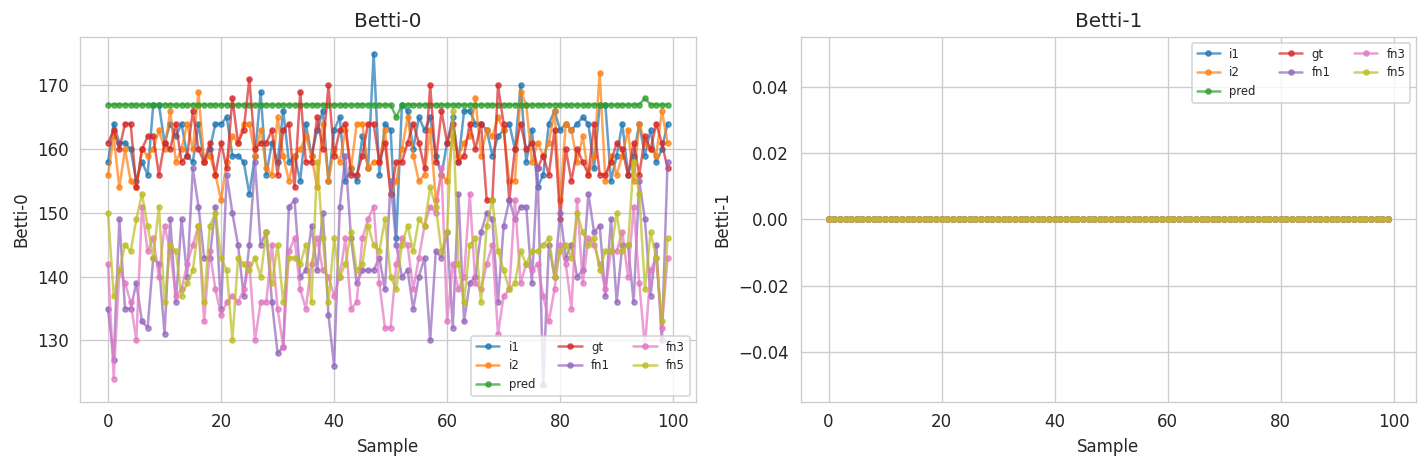

In [9]:
# Betti numbers
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,dim in zip(axes,[0,1]):
    for wt in ['i1','i2','pred','gt','fn1','fn3','fn5']:
        sub=df3[df3['weight_type']==wt]
        ax.plot(sub['sample'],sub[f'betti_{dim}'],'o-',label=wt,alpha=.7,color=COLORS.get(wt,'k'),ms=3)
    ax.set_xlabel('Sample'); ax.set_ylabel(f'Betti-{dim}'); ax.set_title(f'Betti-{dim}'); ax.legend(fontsize=7,ncol=3)
plt.tight_layout(); plt.show()

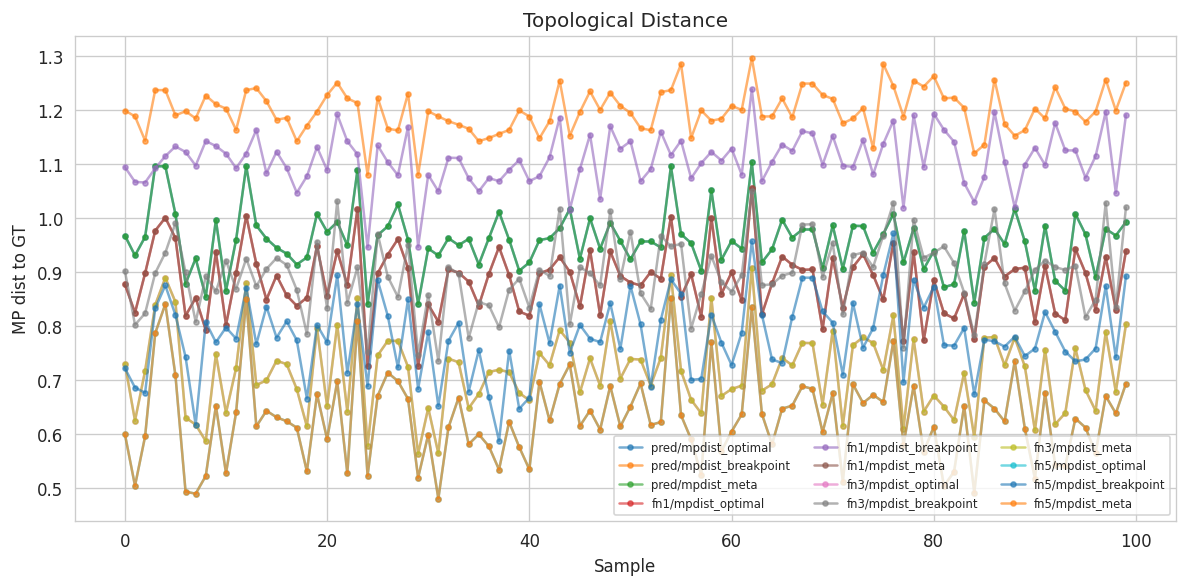

In [10]:
# Multipers distance to GT
mp_cols=[c for c in df3.columns if c.startswith('mpdist_')]
if mp_cols:
    fig,ax=plt.subplots(figsize=(10,5))
    for wt in ['pred','fn1','fn3','fn5']:
        sub=df3[df3['weight_type']==wt]
        for c in mp_cols: ax.plot(sub['sample'],sub[c],'o-',label=f'{wt}/{c}',alpha=.6,ms=3)
    ax.set_xlabel('Sample'); ax.set_ylabel('MP dist to GT'); ax.set_title('Topological Distance'); ax.legend(fontsize=7,ncol=3); plt.tight_layout(); plt.show()

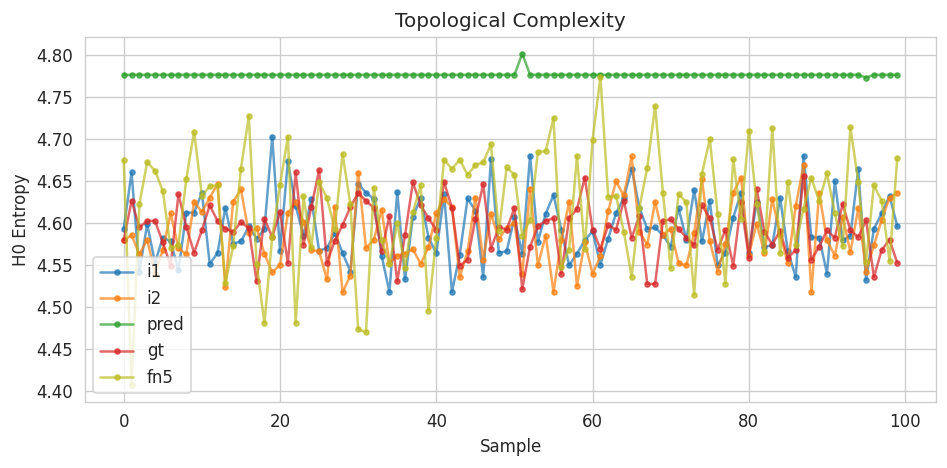

In [11]:
# Persistence entropy
fig,ax=plt.subplots(figsize=(8,4))
for wt in ['i1','i2','pred','gt','fn5']:
    sub=df3[df3['weight_type']==wt]
    ax.plot(sub['sample'],sub['h0_persistence_entropy'],'o-',label=wt,alpha=.7,color=COLORS.get(wt,'k'),ms=3)
ax.set_xlabel('Sample'); ax.set_ylabel('H0 Entropy'); ax.set_title('Topological Complexity'); ax.legend(); plt.tight_layout(); plt.show()

## 5. Fair Evaluation Rankings

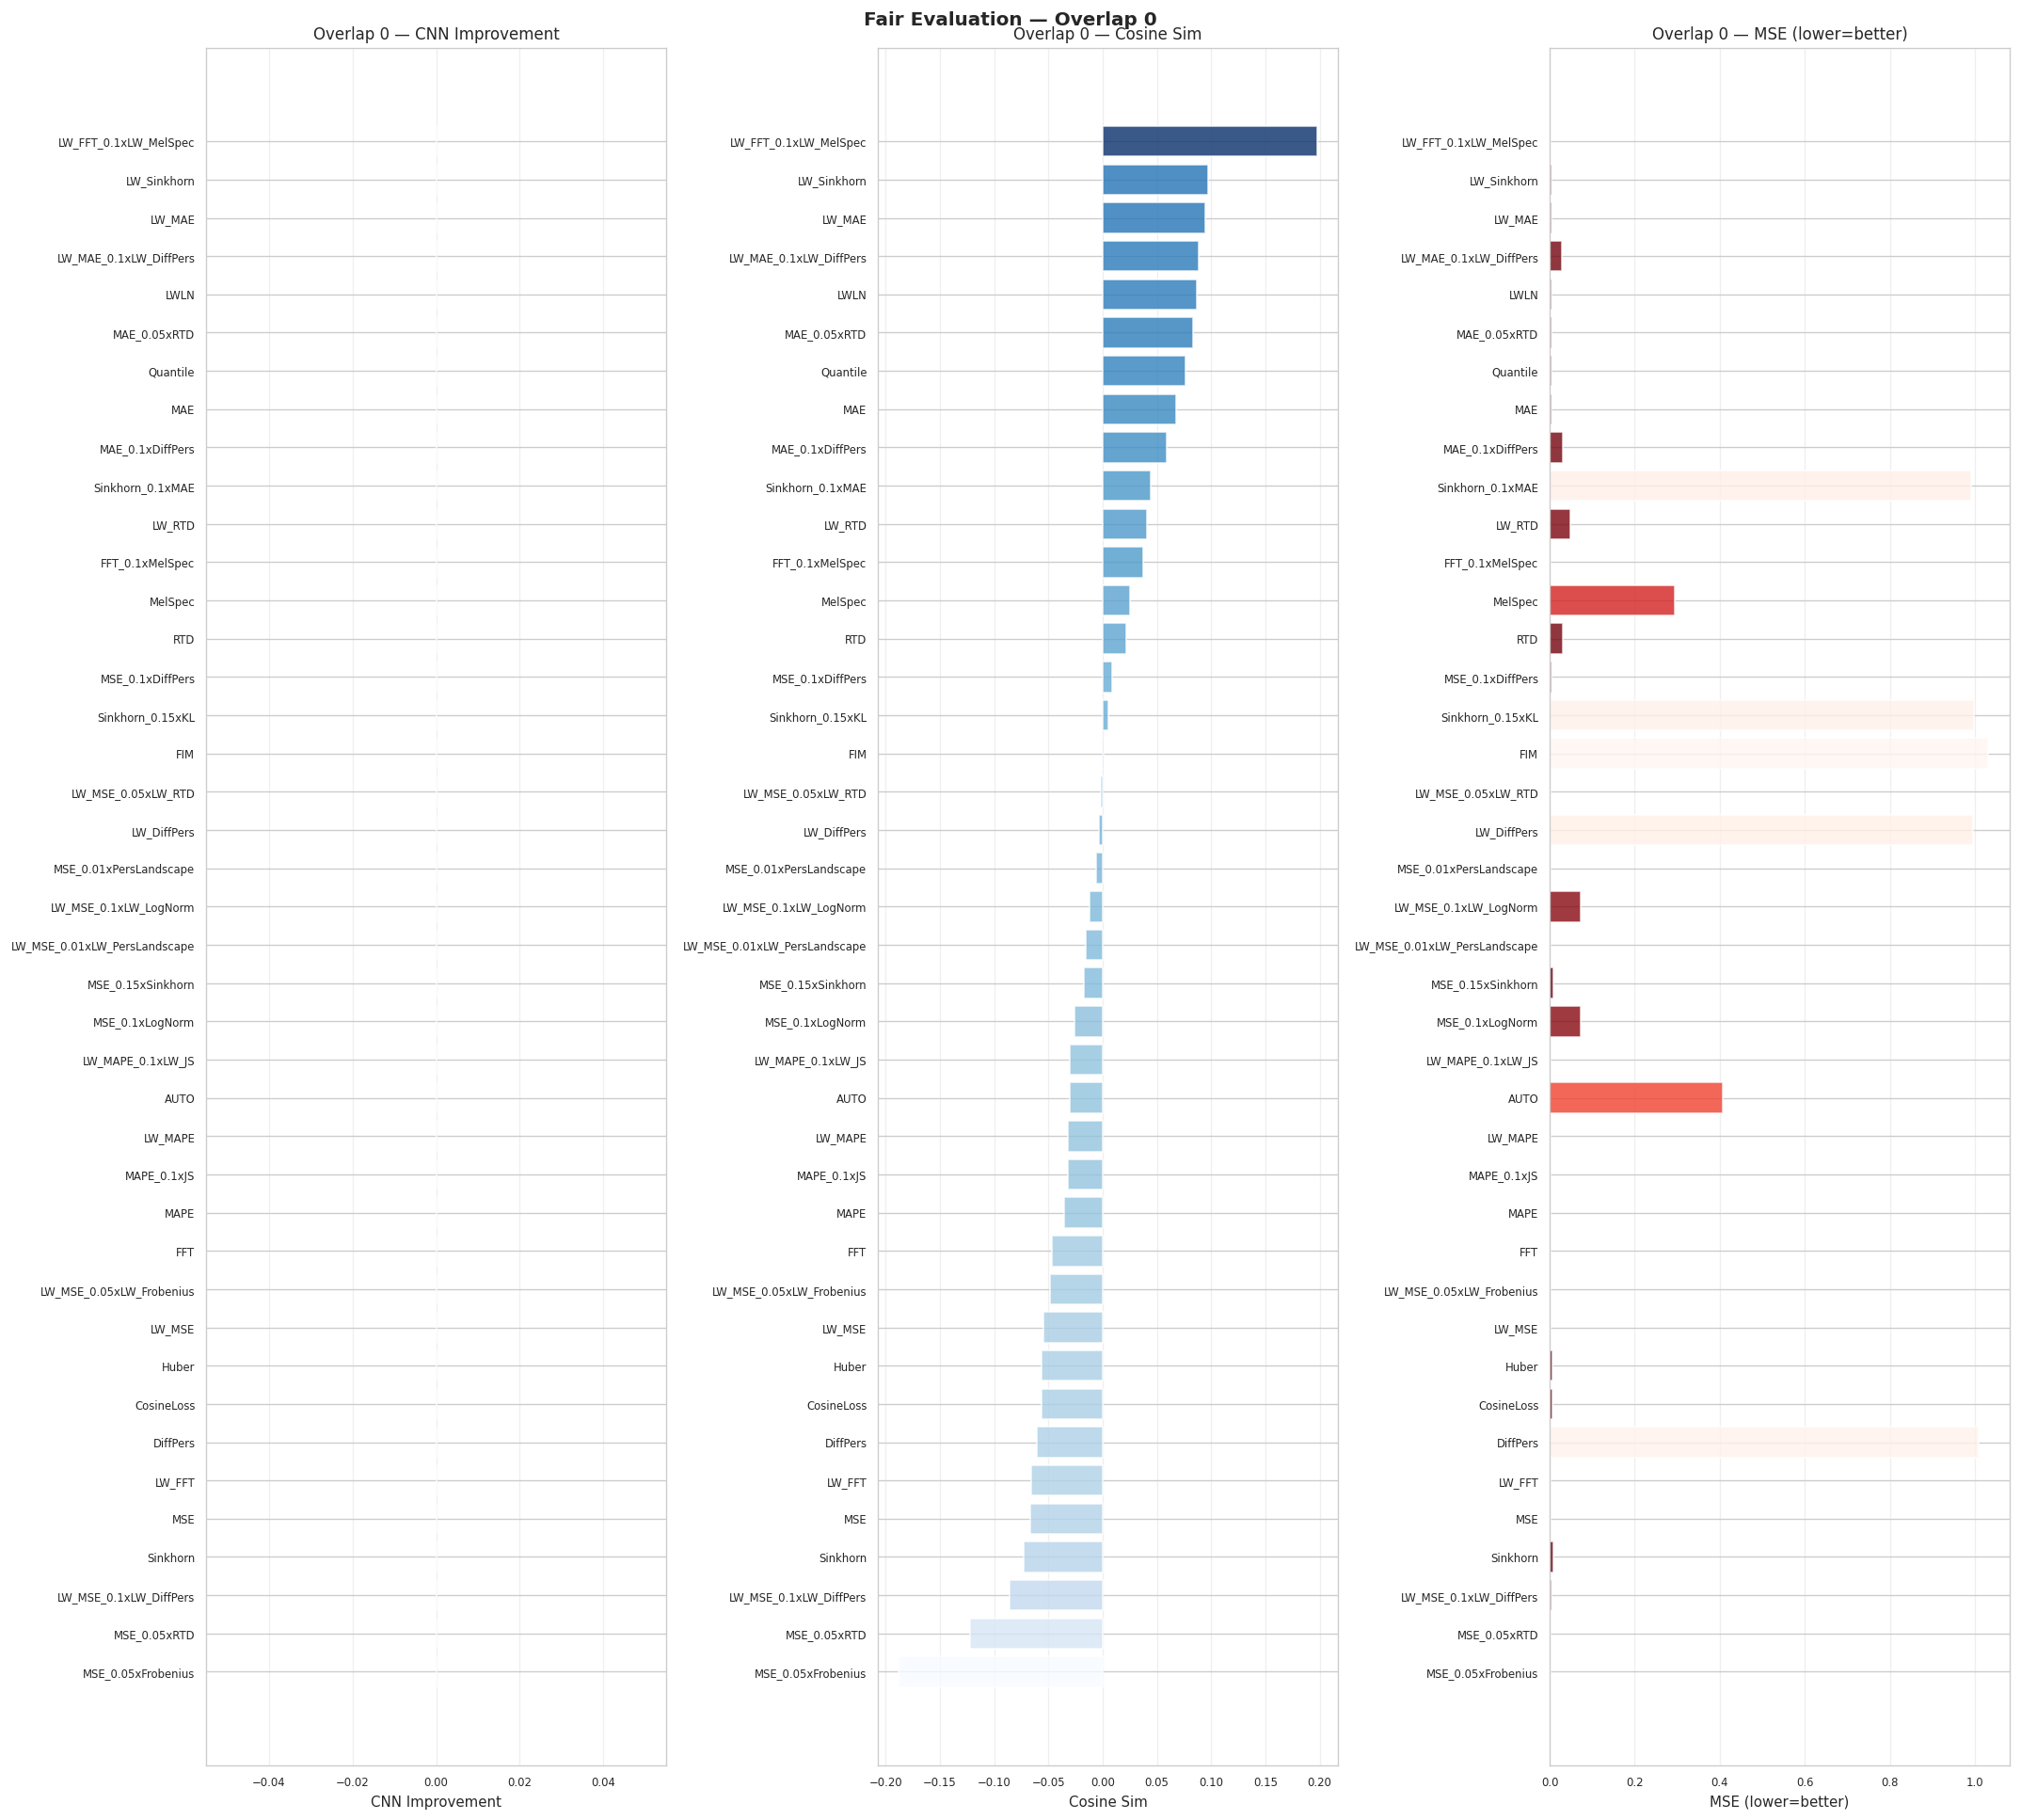

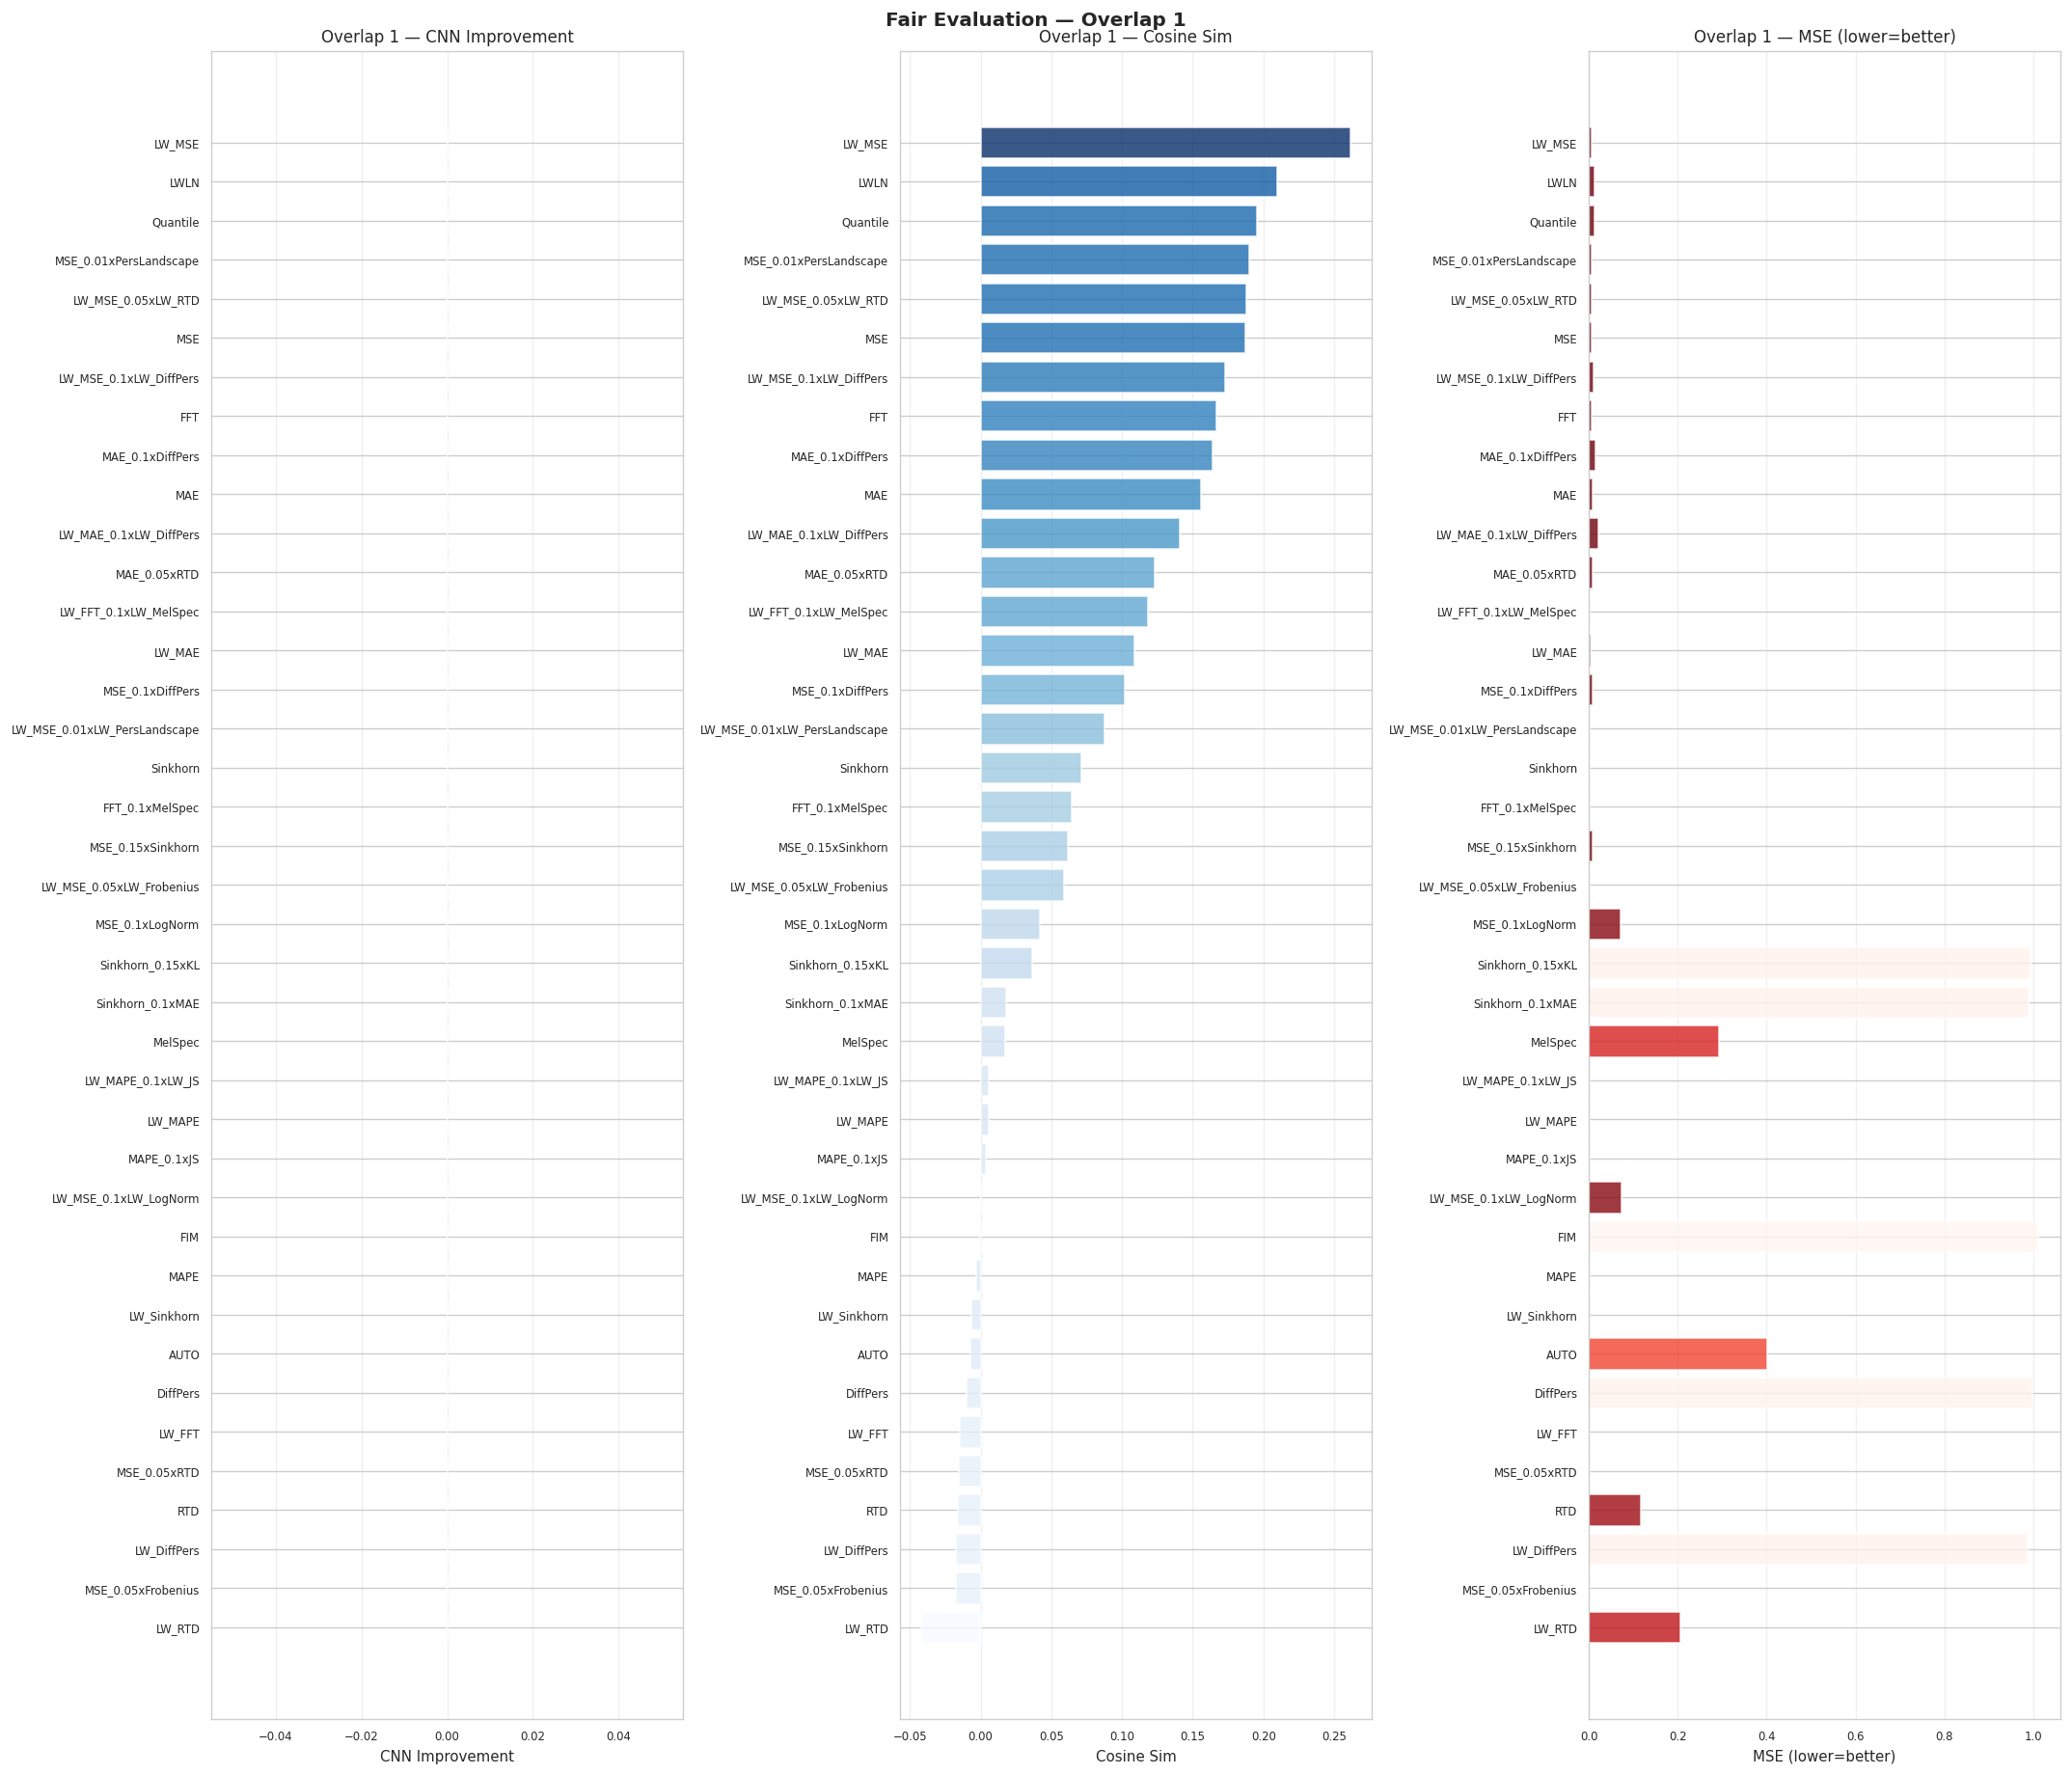

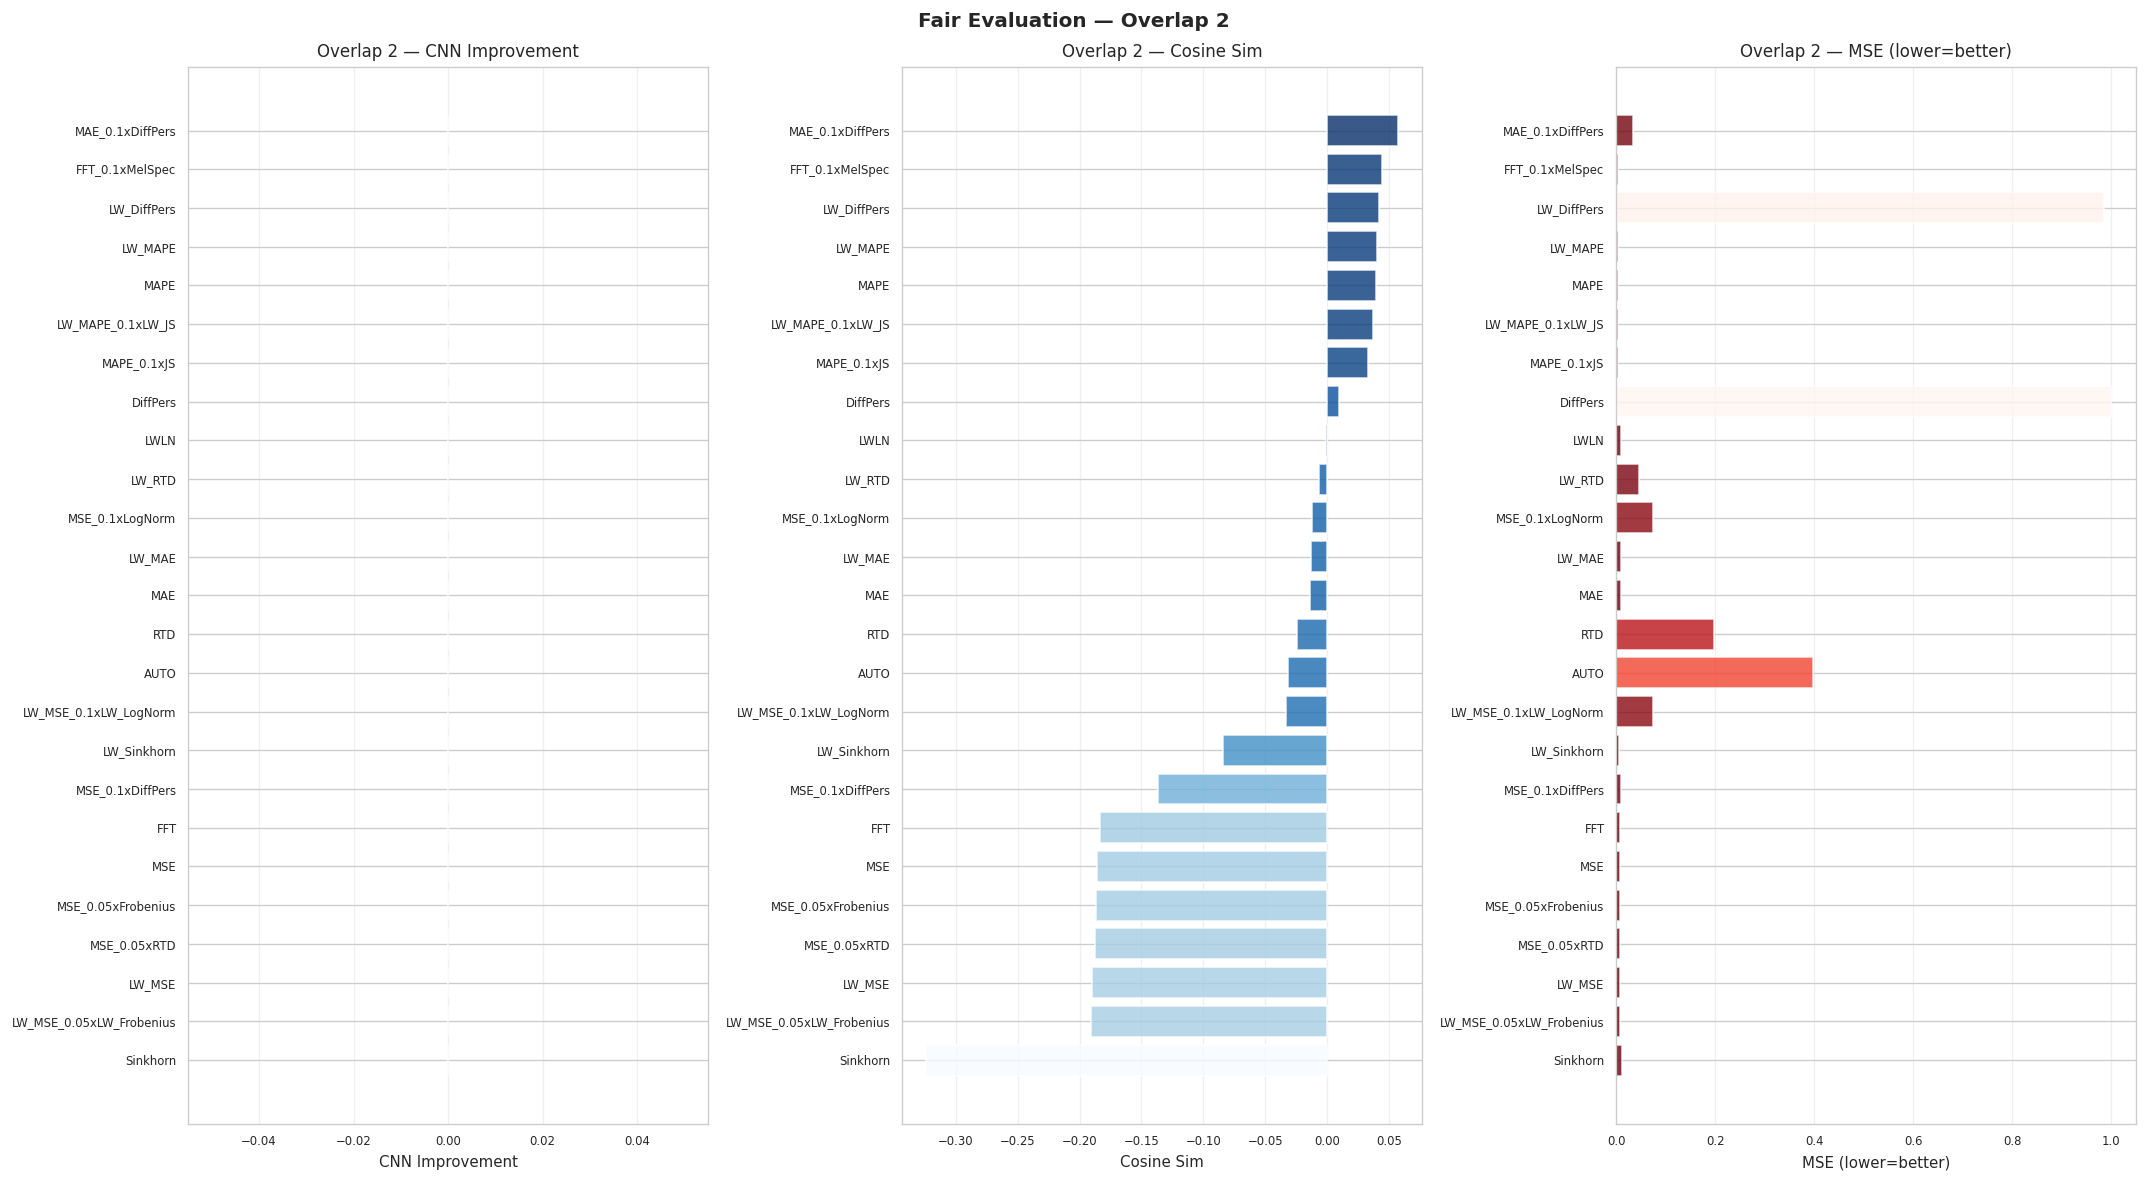

In [12]:
if len(fair_df)>0:
    for ov in sorted(fair_df['overlap'].unique()):
        sub=fair_df[fair_df['overlap']==ov].dropna(subset=['cosine']).sort_values('cosine',ascending=False)
        if sub.empty: continue
        fig,axes=plt.subplots(1,3,figsize=(18,max(6,len(sub)*.4)))
        for ax,col,lbl,cm in [(axes[0],'cnn_improvement','CNN Improvement','RdYlGn'),
                               (axes[1],'cosine','Cosine Sim','Blues'),
                               (axes[2],'mse','MSE (lower=better)','Reds_r')]:
            if col not in sub.columns: continue
            vals=sub[col].fillna(0)
            colors=plt.cm.get_cmap(cm)((vals-vals.min())/(vals.max()-vals.min()+1e-12))
            ax.barh(sub['loss_name'],vals,color=colors,alpha=.8)
            ax.set_xlabel(lbl,fontsize=9); ax.set_title(f'Overlap {ov} — {lbl}',fontsize=10)
            ax.invert_yaxis(); ax.grid(axis='x',alpha=.3); ax.tick_params(labelsize=7)
        plt.suptitle(f'Fair Evaluation — Overlap {ov}',fontsize=12,fontweight='bold')
        plt.tight_layout(); plt.show()
else:
    print('No fair eval data — run cell 0 first')

## 6. Cross-DF Correlations

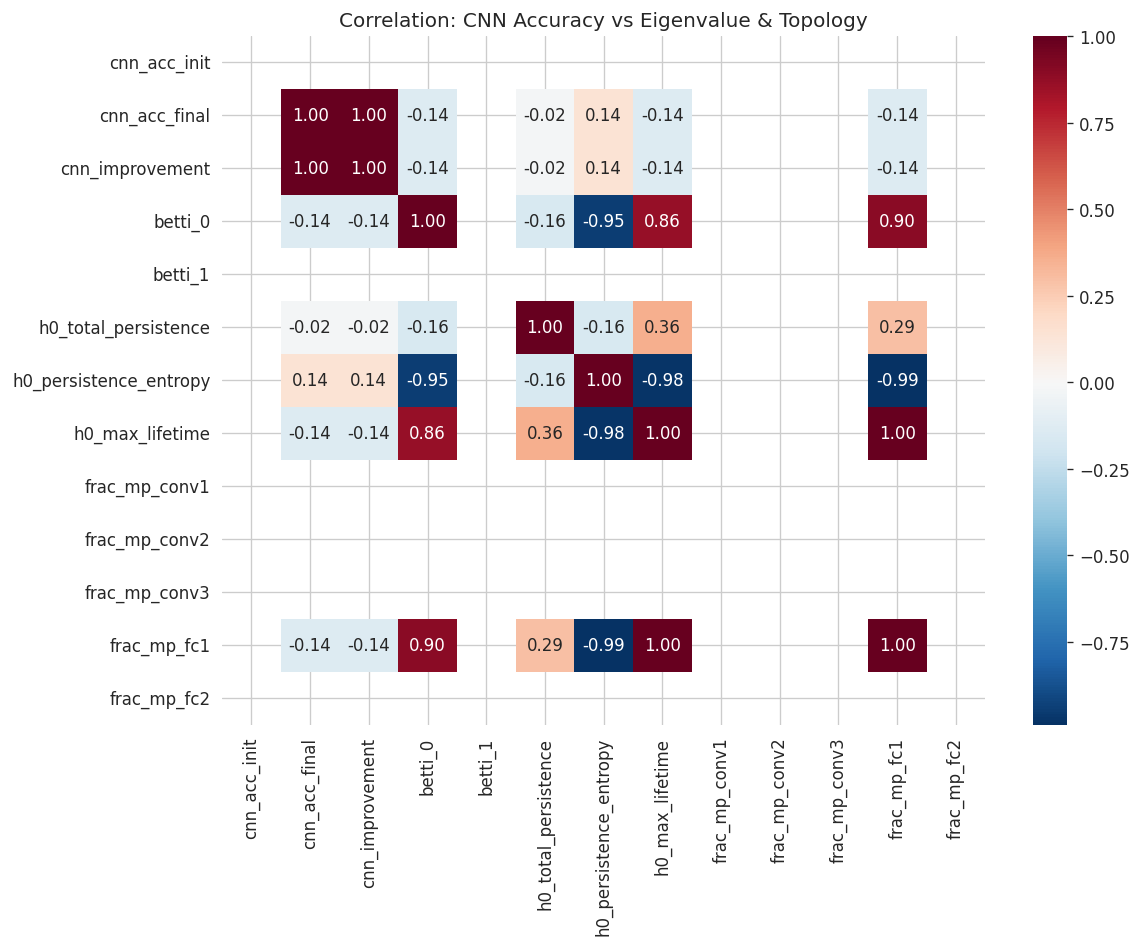

In [13]:
acc_df=df1[['sample','cnn_acc_init','cnn_acc_final']].copy()
acc_df['cnn_improvement']=acc_df['cnn_acc_final']-acc_df['cnn_acc_init']
pred_topo=df3[df3['weight_type']=='pred'][['sample','betti_0','betti_1','h0_total_persistence','h0_persistence_entropy','h0_max_lifetime']].copy()
merged=acc_df.merge(pred_topo,on='sample')
pred_eig=df2[df2['weight_type']=='pred'][['sample']].copy()
for ln in LAYER_NAMES: pred_eig[f'frac_mp_{ln}']=df2[df2['weight_type']=='pred'][f'frac_outside_mp_{ln}'].values
merged=merged.merge(pred_eig,on='sample')
corr=merged.drop(columns=['sample']).corr()
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='RdBu_r',center=0,ax=ax)
ax.set_title('Correlation: CNN Accuracy vs Eigenvalue & Topology'); plt.tight_layout(); plt.show()

## 7. Save Figures to Desktop

In [14]:
FIG_DIR=Path(os.path.expanduser('~/Desktop'))/'deep_analysis_figures'/EXP_NAME
FIG_DIR.mkdir(parents=True,exist_ok=True)
for si in range(min(5,len(df1))):
    fig=plot_weights(si); fig.savefig(FIG_DIR/f'weights_sample{si}.png',bbox_inches='tight'); plt.close(fig)
    fig=plot_fn_mse(si); fig.savefig(FIG_DIR/f'finetune_mse_sample{si}.png',bbox_inches='tight'); plt.close(fig)
    for layer in LAYER_NAMES:
        fig=plot_eig(si,layer); fig.savefig(FIG_DIR/f'eig_{layer}_sample{si}.png',bbox_inches='tight'); plt.close(fig)
# Save fair eval figs
if len(fair_df)>0:
    for ov in sorted(fair_df['overlap'].unique()):
        sub=fair_df[fair_df['overlap']==ov].dropna(subset=['cosine']).sort_values('cosine',ascending=False)
        if sub.empty: continue
        fig,axes=plt.subplots(1,3,figsize=(18,max(6,len(sub)*.4)))
        for ax,col,lbl,cm in [(axes[0],'cnn_improvement','CNN Improvement','RdYlGn'),(axes[1],'cosine','Cosine','Blues'),(axes[2],'mse','MSE','Reds_r')]:
            if col not in sub.columns: continue
            vals=sub[col].fillna(0); colors=plt.cm.get_cmap(cm)((vals-vals.min())/(vals.max()-vals.min()+1e-12))
            ax.barh(sub['loss_name'],vals,color=colors,alpha=.8); ax.set_xlabel(lbl); ax.set_title(f'Overlap {ov} — {lbl}'); ax.invert_yaxis()
        plt.tight_layout(); fig.savefig(FIG_DIR/f'fair_eval_overlap{ov}.png',bbox_inches='tight'); plt.close(fig)
print(f'Saved figures to {FIG_DIR}')

Saved figures to /home/aymen/Desktop/deep_analysis_figures/tiny_overlap0_MSE
